In [57]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import os 
globalpath = "../DataCleaning/A - CSV par bâtiment/"

# Chargement des données
df = pd.read_csv(globalpath+"scaled_dataset_clean.csv")
#df = pd.read_csv(r"C:\Users\Natha\Documents\IR\Projet_IR_JSSN\IR-MetaHeuristics\DataCleaning\A - CSV par bâtiment\batiment_1.csv")
# Séparation X (features) / y (cible)
y = df["production"]
X = df.drop(columns=["production"])


In [58]:
# Split en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Entraînement du modèle RandomForest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Évaluation
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.4f} | R² = {r2:.4f}")


KeyboardInterrupt: 

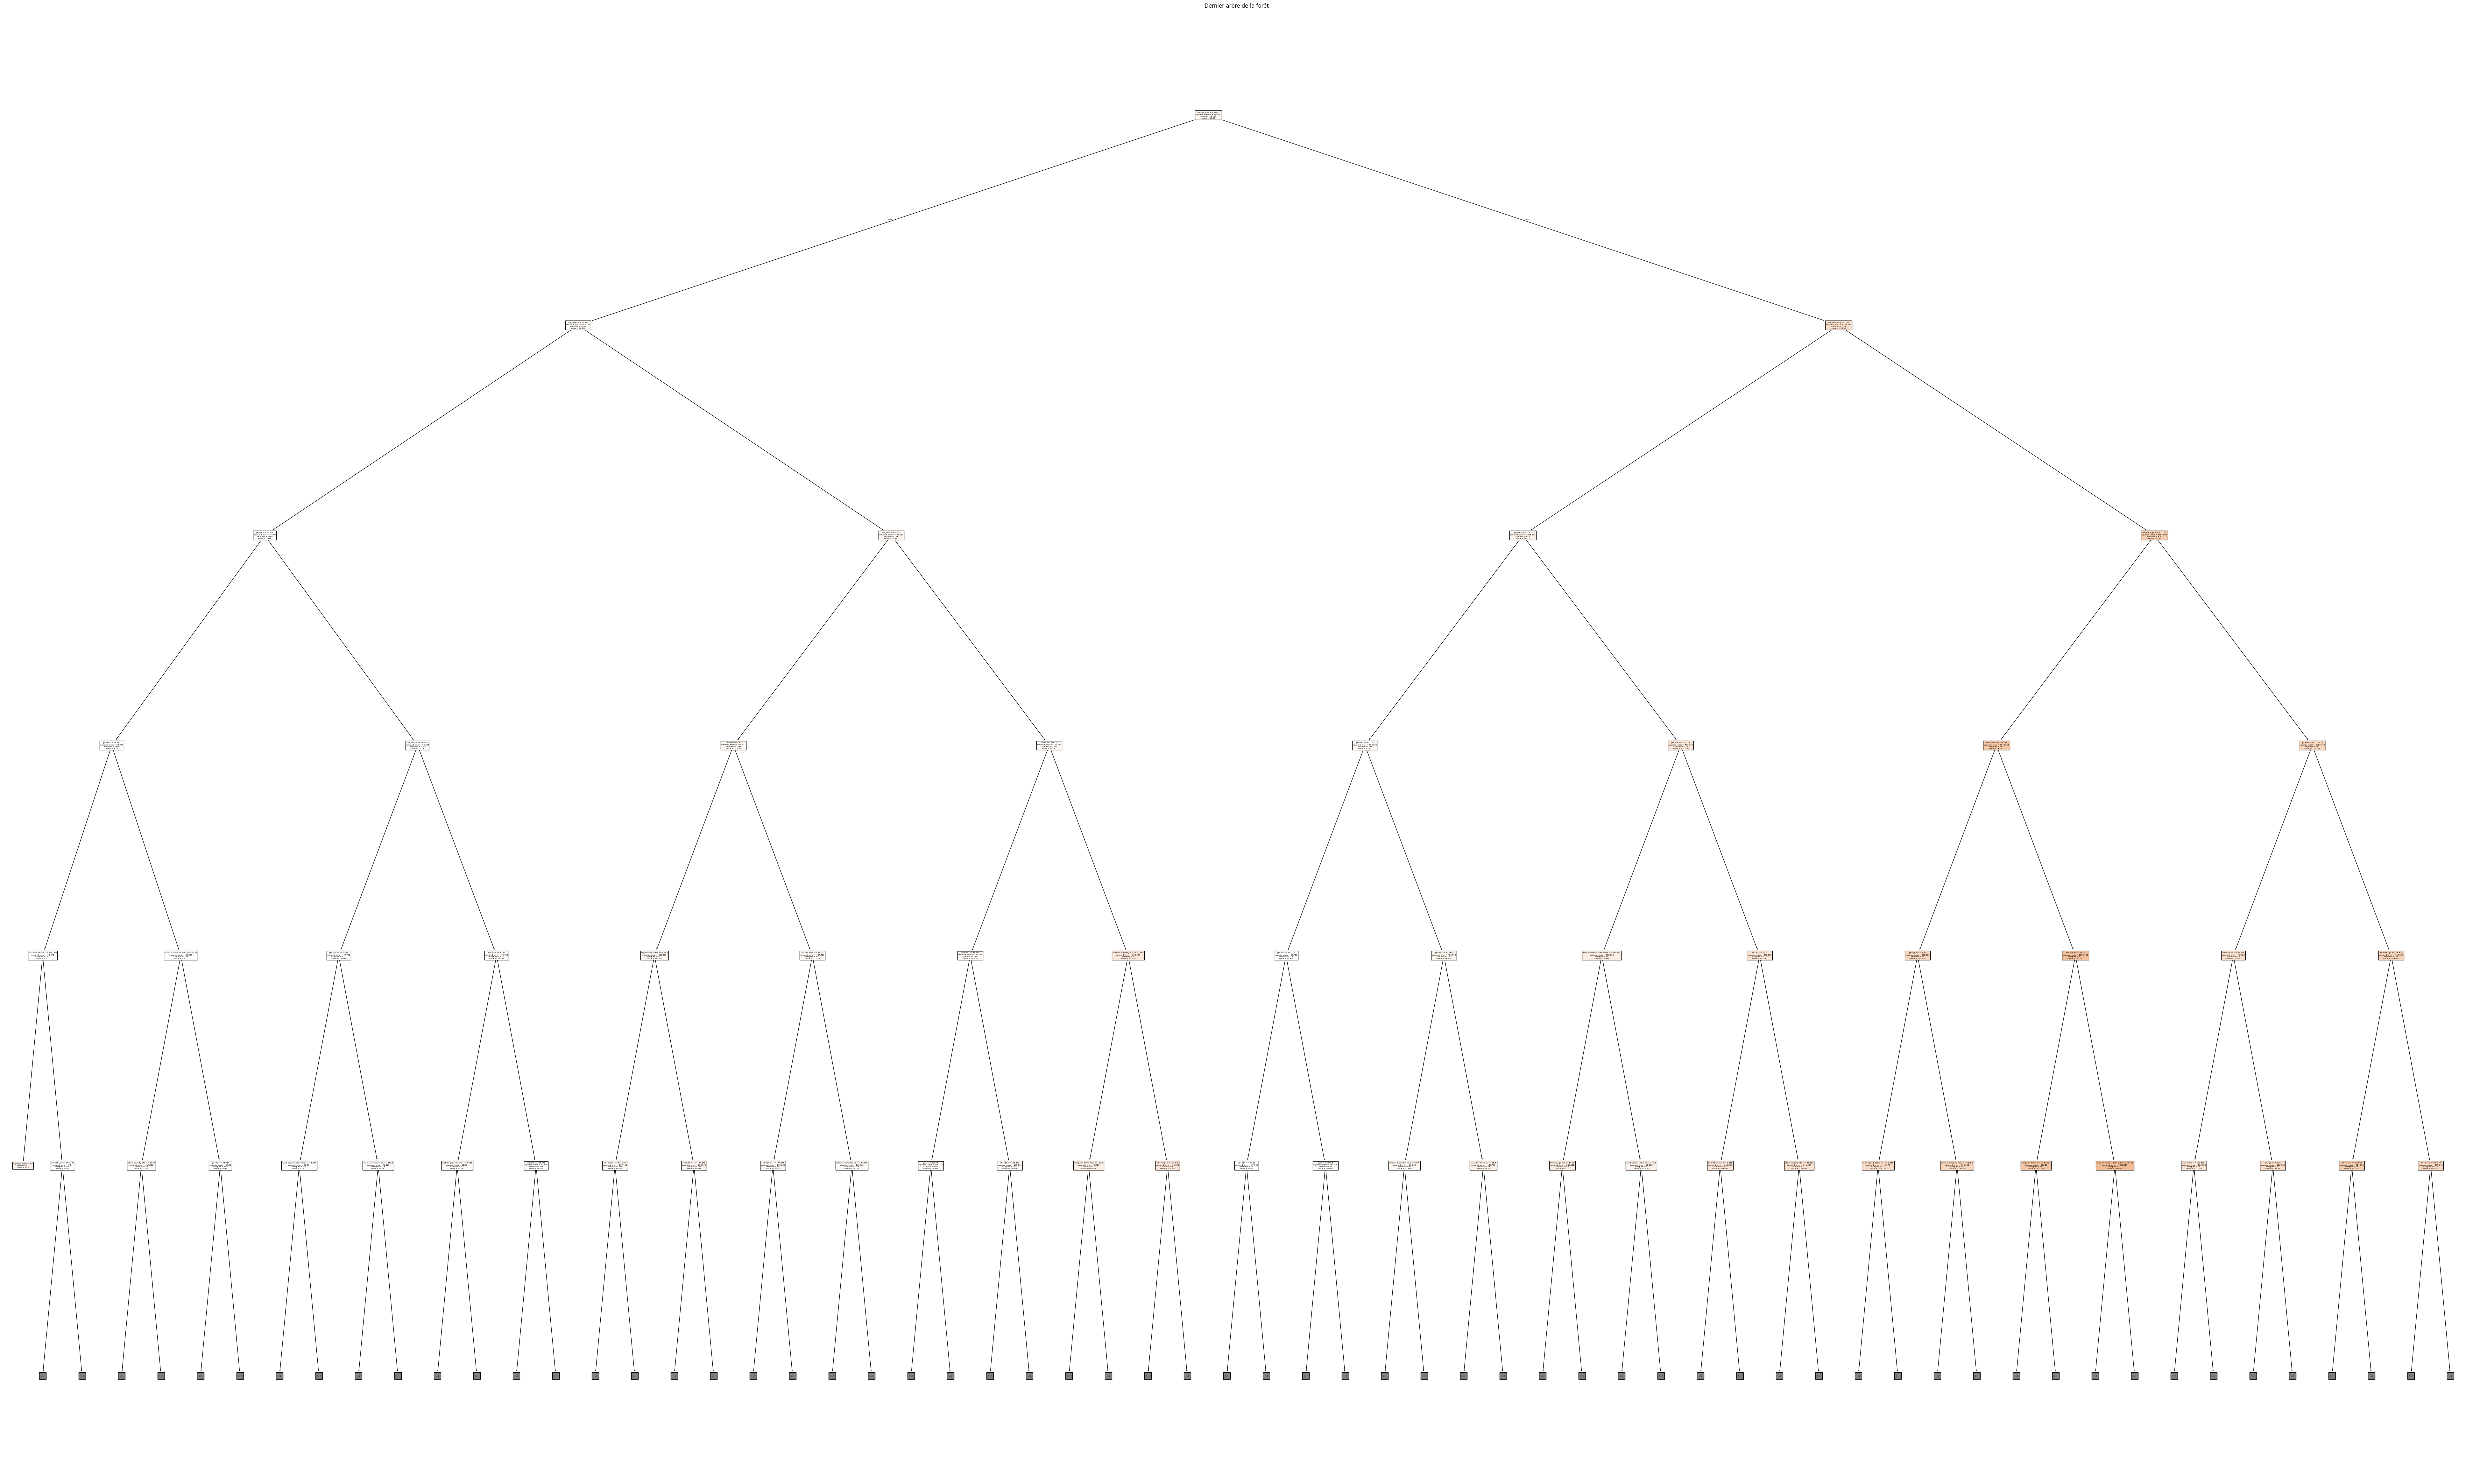

In [ ]:
last_tree = rf.estimators_[-1]  # ou rf.estimators_[199]

# Affichage
plt.figure(figsize=(100, 60))
plot_tree(last_tree, filled=True, feature_names=X.columns, max_depth=5)  # max_depth limite l'affichage
plt.title("Dernier arbre de la forêt")
plt.show()

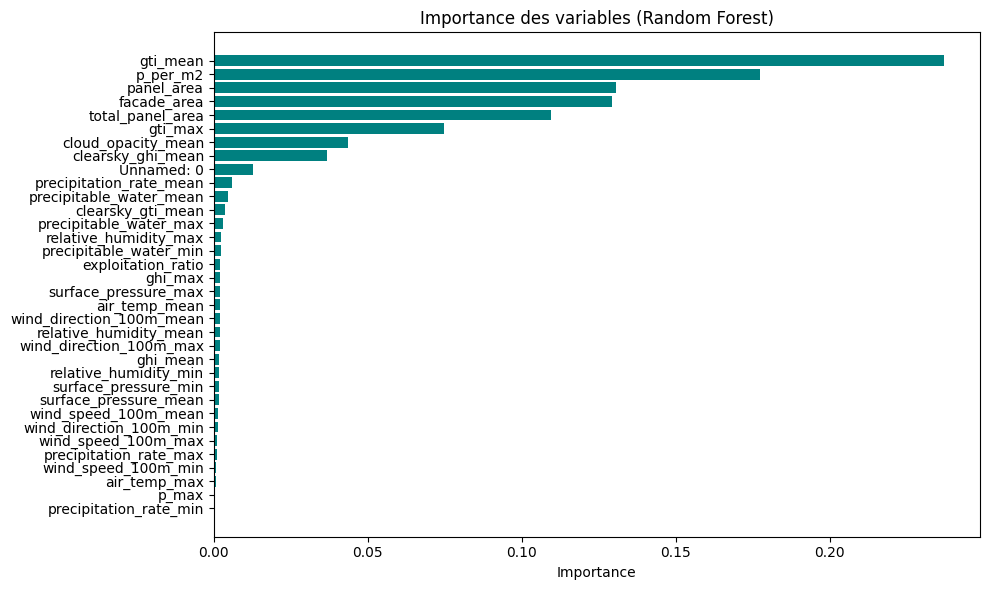

In [ ]:
# Importance des features
importances = rf.feature_importances_
feature_names = X.columns
sorted_idx = importances.argsort()[::-1]

# Affichage
plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx], importances[sorted_idx], color='teal')
plt.xlabel("Importance")
plt.title("Importance des variables (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


9751     38.300
7464      9.400
8621     37.200
1775     56.400
3465      0.500
         ...   
6384    286.708
5572    124.302
590      10.300
5284    286.022
7454     49.800
Name: production, Length: 1078, dtype: float64


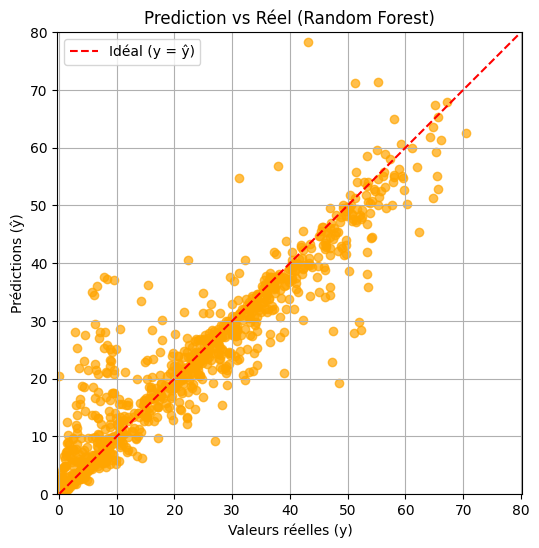

In [59]:
print(y_test)
mask = y_test < 80
ytesti = y_test[mask]
ypredi = y_pred[mask]

plt.figure(figsize=(6, 6))
plt.scatter(ytesti, ypredi, alpha=0.7, color='orange')
plt.plot([min(ytesti), max(ytesti)], [min(ytesti), max(ytesti)], 'r--', label="Idéal (y = ŷ)")
plt.xlabel("Valeurs réelles (y)")
plt.title("Prediction vs Réel (Random Forest)")
plt.ylabel("Prédictions (ŷ)")
plt.axis("equal")
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.legend()
plt.grid(True)
plt.show()
